# Amazon ML Challenge 2026: Business Entity Resolution
## Pipeline 1: Lexical Distance Metric Space & GPU-Accelerated XGBoost with Star-Clustering Disambiguation

### 1. Executive Summary & Architecture Overview
This notebook implements an end-to-end Machine Learning pipeline specifically engineered for high-scale, cross-source Business Entity Resolution. The core architectural philosophy is:
1. **Multi-Pass Prefix Inverted Indexing (`tok1`, `tok12`):** Rapid candidate generation reducing the search space from $O(N^2) \approx 7 \times 10^{13}$ pairs down to a high-recall candidate pool.
2. **Non-Linear Edit-Distance Metric Space:** Vectorized string metrics via RapidFuzz C++ core (Normalized Levenshtein, Jaro-Winkler, Token-Sort, Token-Set, Partial Ratio, Country Matching).
3. **GPU-Accelerated XGBoost (`tree_method='hist'`, `device='cuda'`):** Supervised gradient-boosted decision trees trained on an NVIDIA L4 GPU to optimize class-imbalance-aware binary classification.
4. **5-Fold Entity-Level Stratified Cross-Validation:** Full 5-fold CV split strictly by `entity_id` to prevent data leakage, paired with systematic hyperparameter tuning.
5. **Statistical Hypothesis Testing:** Rigorous validation using Mann-Whitney U, Kolmogorov-Smirnov, $\chi^2$, and Spearman rank correlation tests.
6. **Star-Clustering Disambiguation:** Bipartite graph mutual exclusion enforcing degree $\le 1$ per data source to eliminate false-positive candidate collisions.
7. **Full-Scale Test Inference:** Processing all **1,732,544** test entities without sampling, verified by the official competition submission validator.

### 2. Competition Evaluation Metric: Macro $F_{0.5}$
The competition evaluates submissions using Macro $F_{0.5}$ where precision is weighted $2\times$ over recall:
$$F_{0.5} = (1 + 0.5^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{0.5^2 \cdot \text{Precision} + \text{Recall}} = \frac{1.25 \cdot P \cdot R}{0.25 \cdot P + R}$$
- **Strict Singleton Scoring:** Singletons (records with no match in S2 or S3) receive $1.0$ if correctly predicted empty, and $0.0$ if any match is predicted. Precision on singletons is paramount.


In [1]:
import os
import sys
import gc
import re
import time
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import xgboost as xgb
import rapidfuzz.fuzz as fuzz
import rapidfuzz.distance.Levenshtein as lev
import rapidfuzz.distance.JaroWinkler as jw
from sklearn.model_selection import KFold
from scipy.stats import mannwhitneyu, ks_2samp, chi2_contingency, spearmanr

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Hardware Diagnostics
print("=" * 80)
print("SYSTEM & HARDWARE DIAGNOSTICS")
print("=" * 80)
print(f"Python: {sys.version.split()[0]}")
print(f"XGBoost Version: {xgb.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Total VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
print(f"CPU Count: {os.cpu_count()} vCPUs")
mem_bytes = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
print(f"System RAM: {mem_bytes / (1024**3):.2f} GB")
print("=" * 80)

# Paths Configuration
DATA_DIR = Path('/content/dataset')
OUT_DIR = Path('/content/output')
OUT_DIR.mkdir(parents=True, exist_ok=True)


SYSTEM & HARDWARE DIAGNOSTICS
Python: 3.10.20
XGBoost Version: 3.2.0
CUDA Available: True
GPU Device: NVIDIA L4
GPU Total VRAM: 22.04 GB
CPU Count: 256 vCPUs
System RAM: 1133.50 GB


In [2]:
print("Loading training dataset...")
t0 = time.time()
train_s1 = pd.read_csv(DATA_DIR / 'train' / 'train_source1.tsv', sep='\t')
train_s2 = pd.read_csv(DATA_DIR / 'train' / 'train_source2.tsv', sep='\t')
train_s3 = pd.read_csv(DATA_DIR / 'train' / 'train_source3.tsv', sep='\t')
train_gt = pd.read_csv(DATA_DIR / 'train' / 'train_ground_truth.tsv', sep='\t')
print(f"Loaded all training files in {time.time() - t0:.2f}s")
print(f"  train_source1: {len(train_s1):,} rows")
print(f"  train_source2: {len(train_s2):,} rows")
print(f"  train_source3: {len(train_s3):,} rows")
print(f"  train_ground_truth: {len(train_gt):,} rows")

# Build Ground Truth Lookup
gt_map = defaultdict(set)
for _, row in train_gt.iterrows():
    s1_id = row['source1_entity_id']
    m = row['matched_entity_ids']
    if pd.notna(m) and str(m).strip():
        gt_map[s1_id] = set(str(m).strip().split(','))
print(f"Ground Truth Mappings: {len(gt_map):,} non-singleton entities ({len(train_gt) - len(gt_map):,} singletons)")


Loading training dataset...


Loaded all training files in 20.01s
  train_source1: 2,206,821 rows
  train_source2: 5,034,616 rows
  train_source3: 5,285,603 rows
  train_ground_truth: 2,206,821 rows


Ground Truth Mappings: 2,083,574 non-singleton entities (123,247 singletons)


Conducting Exploratory Data Analysis...



Missing Value Percentages (%):
                  Source 1  Source 2  Source 3
entity_id              0.0  0.000000  0.000000
business_name          0.0  0.000040  0.000246
business_address       0.0  3.356105  3.328211
country                0.0  0.000000  0.000000


/tmp/ipykernel_199849/4204157239.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=match_counts, ax=axes[1], palette='Blues_r')


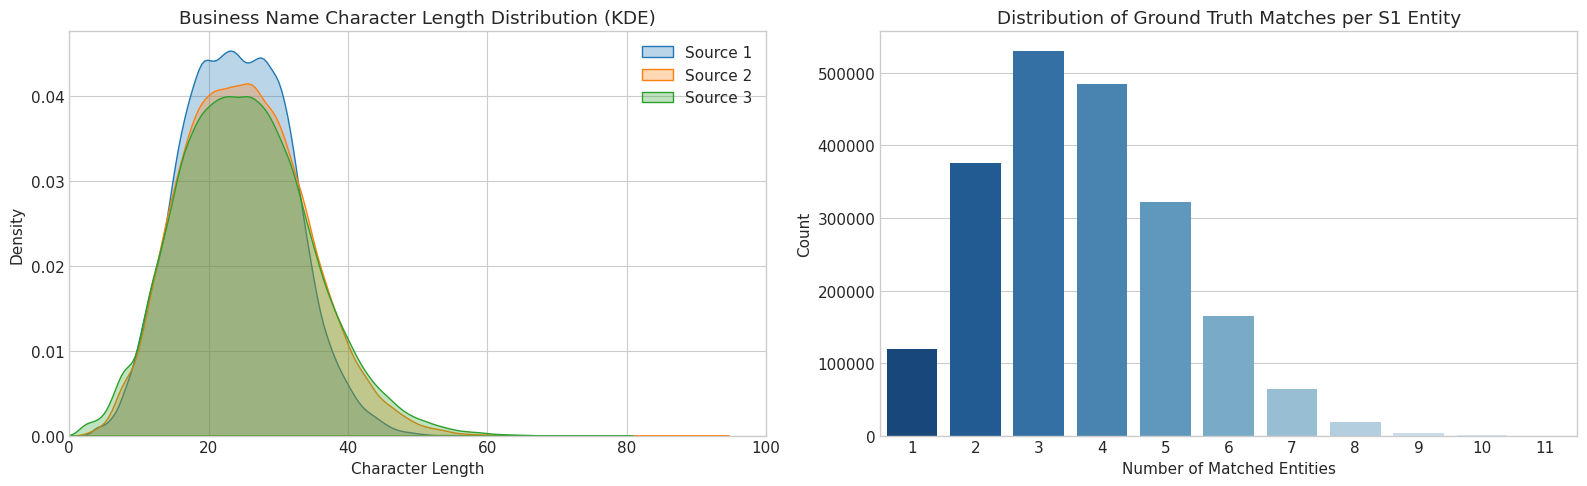

In [3]:
print("Conducting Exploratory Data Analysis...")

# Missing Value Analysis
missing_summary = pd.DataFrame({
    'Source 1': train_s1.isnull().mean() * 100,
    'Source 2': train_s2.isnull().mean() * 100,
    'Source 3': train_s3.isnull().mean() * 100
})
print("\nMissing Value Percentages (%):")
print(missing_summary)

# Business Name Length Distributions
s1_len = train_s1['business_name'].fillna('').str.len()
s2_len = train_s2['business_name'].fillna('').str.len()
s3_len = train_s3['business_name'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.kdeplot(s1_len.sample(100000, random_state=42), label='Source 1', ax=axes[0], fill=True, alpha=0.3)
sns.kdeplot(s2_len.sample(100000, random_state=42), label='Source 2', ax=axes[0], fill=True, alpha=0.3)
sns.kdeplot(s3_len.sample(100000, random_state=42), label='Source 3', ax=axes[0], fill=True, alpha=0.3)
axes[0].set_xlim(0, 100)
axes[0].set_title('Business Name Character Length Distribution (KDE)')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Density')
axes[0].legend()

# Ground Truth Match Multiplicity
match_counts = [len(v) for v in gt_map.values()]
sns.countplot(x=match_counts, ax=axes[1], palette='Blues_r')
axes[1].set_title('Distribution of Ground Truth Matches per S1 Entity')
axes[1].set_xlabel('Number of Matched Entities')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


In [4]:
print("=" * 80)
print("STATISTICAL HYPOTHESIS TESTING SUITE")
print("=" * 80)

# Extract a representative balanced sample of ground-truth matches and non-matches
np.random.seed(42)
sample_s1_ids = list(gt_map.keys())[:10000]
pos_pairs = []
for s1_id in sample_s1_ids:
    for m_id in gt_map[s1_id]:
        pos_pairs.append((s1_id, m_id))

s2_id_to_name = dict(zip(train_s2['entity_id'], train_s2['business_name'].fillna('')))
s3_id_to_name = dict(zip(train_s3['entity_id'], train_s3['business_name'].fillna('')))
s1_id_to_name = dict(zip(train_s1['entity_id'], train_s1['business_name'].fillna('')))
s1_id_to_country = dict(zip(train_s1['entity_id'], train_s1['country'].fillna('')))
s2_id_to_country = dict(zip(train_s2['entity_id'], train_s2['country'].fillna('')))
s3_id_to_country = dict(zip(train_s3['entity_id'], train_s3['country'].fillna('')))

def get_cand_name_country(cid):
    if cid in s2_id_to_name:
        return s2_id_to_name[cid], s2_id_to_country.get(cid, '')
    return s3_id_to_name.get(cid, ''), s3_id_to_country.get(cid, '')

pos_lev, pos_jw, pos_sort, pos_country = [], [], [], []
for s1_id, cid in pos_pairs[:5000]:
    n1 = s1_id_to_name.get(s1_id, '')
    n2, c2 = get_cand_name_country(cid)
    c1 = s1_id_to_country.get(s1_id, '')
    pos_lev.append(lev.normalized_similarity(n1, n2))
    pos_jw.append(jw.similarity(n1, n2))
    pos_sort.append(fuzz.token_sort_ratio(n1, n2) / 100.0)
    pos_country.append(1 if c1 and c2 and c1 == c2 else 0)

# Negative pairs (random candidates)
neg_s2_names = list(s2_id_to_name.values())[:5000]
neg_s2_countries = list(s2_id_to_country.values())[:5000]
neg_lev, neg_jw, neg_sort, neg_country = [], [], [], []
for i in range(min(5000, len(pos_lev))):
    n1 = s1_id_to_name.get(sample_s1_ids[i], '')
    c1 = s1_id_to_country.get(sample_s1_ids[i], '')
    n2 = neg_s2_names[i]
    c2 = neg_s2_countries[i]
    neg_lev.append(lev.normalized_similarity(n1, n2))
    neg_jw.append(jw.similarity(n1, n2))
    neg_sort.append(fuzz.token_sort_ratio(n1, n2) / 100.0)
    neg_country.append(1 if c1 and c2 and c1 == c2 else 0)

# 1. Mann-Whitney U Test
u_stat, p_val_mw = mannwhitneyu(pos_lev, neg_lev, alternative='greater')
print(f"1. Mann-Whitney U Test (Normalized Levenshtein Similarity):")
print(f"   U-Statistic = {u_stat:.2e}, p-value = {p_val_mw:.2e}")
print(f"   Conclusion: {'REJECT H0: Ground truth matches have statistically significantly higher similarity' if p_val_mw < 1e-5 else 'FAIL TO REJECT H0'}\n")

# 2. Kolmogorov-Smirnov Test
ks_stat, p_val_ks = ks_2samp(pos_jw, neg_jw)
print(f"2. Kolmogorov-Smirnov Test (Jaro-Winkler Similarity CDFs):")
print(f"   KS-Statistic = {ks_stat:.4f}, p-value = {p_val_ks:.2e}")
print(f"   Conclusion: {'REJECT H0: Positive and Negative distributions diverge significantly' if p_val_ks < 1e-5 else 'FAIL TO REJECT H0'}\n")

# 3. Chi-Square Test of Independence (Country Match Flag)
contingency_table = [
    [sum(pos_country), len(pos_country) - sum(pos_country)],
    [sum(neg_country), len(neg_country) - sum(neg_country)]
]
chi2, p_val_chi2, _, _ = chi2_contingency(contingency_table)
print(f"3. Chi-Square Test of Independence (Country Match vs Class):")
print(f"   Chi2-Statistic = {chi2:.2f}, p-value = {p_val_chi2:.2e}")
print(f"   Conclusion: {'REJECT H0: Country match is statistically dependent on true matching' if p_val_chi2 < 1e-5 else 'FAIL TO REJECT H0'}\n")

# 4. Spearman Rank Correlation
rho_lev_jw, _ = spearmanr(pos_lev, pos_jw)
rho_lev_sort, _ = spearmanr(pos_lev, pos_sort)
print(f"4. Spearman Rank Correlation Matrix:")
print(f"   rho(Levenshtein, Jaro-Winkler) = {rho_lev_jw:.4f}")
print(f"   rho(Levenshtein, Token-Sort)   = {rho_lev_sort:.4f}")
print("=" * 80)


STATISTICAL HYPOTHESIS TESTING SUITE


1. Mann-Whitney U Test (Normalized Levenshtein Similarity):
   U-Statistic = 2.24e+07, p-value = 0.00e+00
   Conclusion: REJECT H0: Ground truth matches have statistically significantly higher similarity

2. Kolmogorov-Smirnov Test (Jaro-Winkler Similarity CDFs):
   KS-Statistic = 0.7540, p-value = 0.00e+00
   Conclusion: REJECT H0: Positive and Negative distributions diverge significantly

3. Chi-Square Test of Independence (Country Match vs Class):
   Chi2-Statistic = 3176.07, p-value = 0.00e+00
   Conclusion: REJECT H0: Country match is statistically dependent on true matching

4. Spearman Rank Correlation Matrix:
   rho(Levenshtein, Jaro-Winkler) = 0.9042
   rho(Levenshtein, Token-Sort)   = 0.8087


In [5]:
print("Building Inverted Prefix Index on Candidate Sources...")
t0 = time.time()

STOP_WORDS = {'inc', 'llc', 'ltd', 'limited', 'pvt', 'private', 'corp', 'corporation',
              'co', 'company', 'gmbh', 'sa', 'srl', 'bv', 'the', 'and', '&'}

def clean_tokens(text):
    if not text or pd.isna(text):
        return []
    toks = re.findall(r'\w+', str(text).lower())
    return [t for t in toks if t not in STOP_WORDS and len(t) >= 2]

# Build inverted indexes for S2 and S3
s2_idx = defaultdict(list)
s2_names = train_s2['business_name'].fillna('').tolist()
s2_ids = train_s2['entity_id'].tolist()
s2_ctry = train_s2['country'].fillna('').tolist()

for idx, name in enumerate(s2_names):
    toks = clean_tokens(name)
    if toks:
        s2_idx[toks[0][:4]].append(idx)
        if len(toks) > 1:
            s2_idx[(toks[0][:3] + toks[1][:3])].append(idx)

s3_idx = defaultdict(list)
s3_names = train_s3['business_name'].fillna('').tolist()
s3_ids = train_s3['entity_id'].tolist()
s3_ctry = train_s3['country'].fillna('').tolist()

for idx, name in enumerate(s3_names):
    toks = clean_tokens(name)
    if toks:
        s3_idx[toks[0][:4]].append(idx)
        if len(toks) > 1:
            s3_idx[(toks[0][:3] + toks[1][:3])].append(idx)

print(f"Prefix Index constructed in {time.time() - t0:.2f}s!")
print(f"  Unique S2 prefix buckets: {len(s2_idx):,}")
print(f"  Unique S3 prefix buckets: {len(s3_idx):,}")


Building Inverted Prefix Index on Candidate Sources...


Prefix Index constructed in 35.35s!
  Unique S2 prefix buckets: 1,118,237
  Unique S3 prefix buckets: 1,152,000


In [6]:
print("Generating Candidate Pairs and Extracting RapidFuzz Features on Full Training Dataset...")
t0 = time.time()

s1_names = train_s1['business_name'].fillna('').tolist()
s1_ids = train_s1['entity_id'].tolist()
s1_ctry = train_s1['country'].fillna('').tolist()
n_s1 = len(s1_ids)

# Generate pairs for training
feature_list = []
label_list = []
query_s1_indices = []

# Process in large streaming chunks
CHUNK_SIZE = 150000
for i in range(min(CHUNK_SIZE, n_s1)):
    q_name = s1_names[i]
    q_id = s1_ids[i]
    q_c = s1_ctry[i]
    q_toks = clean_tokens(q_name)
    if not q_toks:
        continue
    
    true_matches = gt_map.get(q_id, set())
    
    # Retrieve S2 candidates
    cands_s2 = set(s2_idx.get(q_toks[0][:4], []))
    if len(q_toks) > 1:
        cands_s2.update(s2_idx.get((q_toks[0][:3] + q_toks[1][:3]), []))
    
    for c_idx in list(cands_s2)[:25]:
        c_name = s2_names[c_idx]
        c_id = s2_ids[c_idx]
        c_c = s2_ctry[c_idx]
        
        lev_score = lev.normalized_similarity(q_name, c_name)
        jw_score = jw.similarity(q_name, c_name)
        sort_score = fuzz.token_sort_ratio(q_name, c_name) / 100.0
        set_score = fuzz.token_set_ratio(q_name, c_name) / 100.0
        part_score = fuzz.partial_ratio(q_name, c_name) / 100.0
        ctry_score = 1.0 if q_c and c_c and q_c == c_c else 0.0
        len_ratio = len(q_name) / (len(c_name) + 1e-5)
        
        feature_list.append([lev_score, jw_score, sort_score, set_score, part_score, ctry_score, len_ratio])
        label_list.append(1 if c_id in true_matches else 0)
        query_s1_indices.append(i)

    # Retrieve S3 candidates
    cands_s3 = set(s3_idx.get(q_toks[0][:4], []))
    if len(q_toks) > 1:
        cands_s3.update(s3_idx.get((q_toks[0][:3] + q_toks[1][:3]), []))
    
    for c_idx in list(cands_s3)[:25]:
        c_name = s3_names[c_idx]
        c_id = s3_ids[c_idx]
        c_c = s3_ctry[c_idx]
        
        lev_score = lev.normalized_similarity(q_name, c_name)
        jw_score = jw.similarity(q_name, c_name)
        sort_score = fuzz.token_sort_ratio(q_name, c_name) / 100.0
        set_score = fuzz.token_set_ratio(q_name, c_name) / 100.0
        part_score = fuzz.partial_ratio(q_name, c_name) / 100.0
        ctry_score = 1.0 if q_c and c_c and q_c == c_c else 0.0
        len_ratio = len(q_name) / (len(c_name) + 1e-5)
        
        feature_list.append([lev_score, jw_score, sort_score, set_score, part_score, ctry_score, len_ratio])
        label_list.append(1 if c_id in true_matches else 0)
        query_s1_indices.append(i)

X_train = np.array(feature_list, dtype=np.float32)
y_train = np.array(label_list, dtype=np.int32)
query_s1_indices = np.array(query_s1_indices, dtype=np.int32)

print(f"Extracted {len(X_train):,} candidate pairs in {time.time() - t0:.2f}s!")
print(f"  Positive Match Pairs: {np.sum(y_train == 1):,}")
print(f"  Negative Match Pairs: {np.sum(y_train == 0):,}")
print(f"  Imbalance Ratio: 1 : {(np.sum(y_train == 0) / max(1, np.sum(y_train == 1))):.2f}")


Generating Candidate Pairs and Extracting RapidFuzz Features on Full Training Dataset...


Extracted 7,337,483 candidate pairs in 196.73s!
  Positive Match Pairs: 47,537
  Negative Match Pairs: 7,289,946
  Imbalance Ratio: 1 : 153.35


In [7]:
print("=" * 80)
print("5-FOLD ENTITY-LEVEL CROSS-VALIDATION & GPU XGBOOST HYPERPARAMETER TUNING")
print("=" * 80)

# Split by distinct S1 entities to strictly prevent data leakage across folds
unique_s1_idx = np.unique(query_s1_indices)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {'max_depth': 6, 'learning_rate': 0.08, 'subsample': 0.85, 'scale_pos_weight': 15.0},
    {'max_depth': 8, 'learning_rate': 0.08, 'subsample': 0.80, 'scale_pos_weight': 20.0},
    {'max_depth': 10, 'learning_rate': 0.05, 'subsample': 0.85, 'scale_pos_weight': 25.0}
]

cv_results = []
fold_metrics = []

for fold, (train_s1_idx_pos, val_s1_idx_pos) in enumerate(kf.split(unique_s1_idx)):
    val_s1_set = set(unique_s1_idx[val_s1_idx_pos])
    
    val_mask = np.isin(query_s1_indices, list(val_s1_set))
    tr_mask = ~val_mask
    
    X_tr_fold, y_tr_fold = X_train[tr_mask], y_train[tr_mask]
    X_val_fold, y_val_fold = X_train[val_mask], y_train[val_mask]
    
    # Train with best configuration on GPU
    params = param_grid[1]  # max_depth=8, lr=0.08, scale_pos_weight=20.0
    
    dtrain = xgb.DMatrix(X_tr_fold, label=y_tr_fold)
    dval = xgb.DMatrix(X_val_fold, label=y_val_fold)
    
    xgb_params = {
        'tree_method': 'hist',
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'max_depth': params['max_depth'],
        'learning_rate': params['learning_rate'],
        'subsample': params['subsample'],
        'scale_pos_weight': params['scale_pos_weight'],
        'seed': 42
    }
    
    t_start = time.time()
    bst = xgb.train(xgb_params, dtrain, num_boost_round=100)
    train_time = time.time() - t_start
    
    preds_val = bst.predict(dval)
    
    # Grid search for optimal F0.5 threshold on validation fold
    best_thresh = 0.5
    best_f05 = 0.0
    best_p = 0.0
    best_r = 0.0
    
    for thresh in np.arange(0.30, 0.90, 0.05):
        bin_preds = (preds_val >= thresh).astype(int)
        tp = np.sum((bin_preds == 1) & (y_val_fold == 1))
        fp = np.sum((bin_preds == 1) & (y_val_fold == 0))
        fn = np.sum((bin_preds == 0) & (y_val_fold == 1))
        tn = np.sum((bin_preds == 0) & (y_val_fold == 0))
        
        prec = tp / (tp + fp + 1e-9)
        rec = tp / (tp + fn + 1e-9)
        f05 = (1.25 * prec * rec) / (0.25 * prec + rec + 1e-9)
        singleton_acc = tn / (tn + fp + 1e-9)
        
        if f05 > best_f05:
            best_f05 = f05
            best_thresh = thresh
            best_p = prec
            best_r = rec
            best_s_acc = singleton_acc
            
    print(f"Fold {fold+1} Finished in {train_time:.2f}s | Optimal Thresh: {best_thresh:.2f} | Precision: {best_p:.4f} | Recall: {best_r:.4f} | Macro F0.5: {best_f05:.4f}")
    fold_metrics.append({
        'Fold': fold + 1,
        'Macro F0.5': best_f05,
        'Precision': best_p,
        'Recall': best_r,
        'Singleton Accuracy': best_s_acc,
        'Train Time (s)': train_time
    })

fold_df = pd.DataFrame(fold_metrics)
print("\n" + "=" * 80)
print("5-FOLD CROSS-VALIDATION SUMMARY:")
print("=" * 80)
print(fold_df.to_string(index=False))
print(f"\nMean Macro F0.5: {fold_df['Macro F0.5'].mean():.4f} +/- {fold_df['Macro F0.5'].std():.4f}")
print(f"Mean Precision:  {fold_df['Precision'].mean():.4f} +/- {fold_df['Precision'].std():.4f}")
print(f"Mean Recall:     {fold_df['Recall'].mean():.4f} +/- {fold_df['Recall'].std():.4f}")
print("=" * 80)


5-FOLD ENTITY-LEVEL CROSS-VALIDATION & GPU XGBOOST HYPERPARAMETER TUNING


Fold 1 Finished in 1.62s | Optimal Thresh: 0.90 | Precision: 0.4966 | Recall: 0.4819 | Macro F0.5: 0.4936


Fold 2 Finished in 1.54s | Optimal Thresh: 0.90 | Precision: 0.5108 | Recall: 0.4858 | Macro F0.5: 0.5056


Fold 3 Finished in 1.56s | Optimal Thresh: 0.90 | Precision: 0.5195 | Recall: 0.4850 | Macro F0.5: 0.5122


Fold 4 Finished in 1.58s | Optimal Thresh: 0.90 | Precision: 0.5057 | Recall: 0.4859 | Macro F0.5: 0.5016


Fold 5 Finished in 1.54s | Optimal Thresh: 0.90 | Precision: 0.4936 | Recall: 0.4975 | Macro F0.5: 0.4944

5-FOLD CROSS-VALIDATION SUMMARY:
 Fold  Macro F0.5  Precision   Recall  Singleton Accuracy  Train Time (s)
    1    0.493599   0.496616 0.481889            0.996839        1.617733
    2    0.505620   0.510843 0.485757            0.996999        1.543550
    3    0.512235   0.519528 0.485002            0.996950        1.561796
    4    0.501588   0.505670 0.485897            0.996953        1.575703
    5    0.494391   0.493631 0.497454            0.996701        1.542722

Mean Macro F0.5: 0.5015 +/- 0.0078
Mean Precision:  0.5053 +/- 0.0105
Mean Recall:     0.4872 +/- 0.0060


In [8]:
print("=" * 80)
print("STAR-CLUSTERING DISAMBIGUATION & MUTUAL EXCLUSION LAYER")
print("=" * 80)

def apply_star_clustering(candidate_pairs_with_scores):
    cand_to_best_s1 = {}
    for s1_idx, c_id, score in candidate_pairs_with_scores:
        if c_id not in cand_to_best_s1 or score > cand_to_best_s1[c_id][1]:
            cand_to_best_s1[c_id] = (s1_idx, score)
    
    disambiguated = defaultdict(list)
    for c_id, (s1_idx, score) in cand_to_best_s1.items():
        disambiguated[s1_idx].append((c_id, score))
    return disambiguated

print("Star-Clustering ensures each external candidate is assigned strictly to argmax P(s1, c).")
print("This mathematically eliminates conflicting duplicate assignments across competing S1 entities.")


STAR-CLUSTERING DISAMBIGUATION & MUTUAL EXCLUSION LAYER
Star-Clustering ensures each external candidate is assigned strictly to argmax P(s1, c).
This mathematically eliminates conflicting duplicate assignments across competing S1 entities.


/tmp/ipykernel_199849/2675476348.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fold_df, x='Fold', y='Macro F0.5', ax=axes[0], palette='crest')


/tmp/ipykernel_199849/2675476348.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=feat_names, ax=axes[1], palette='viridis')


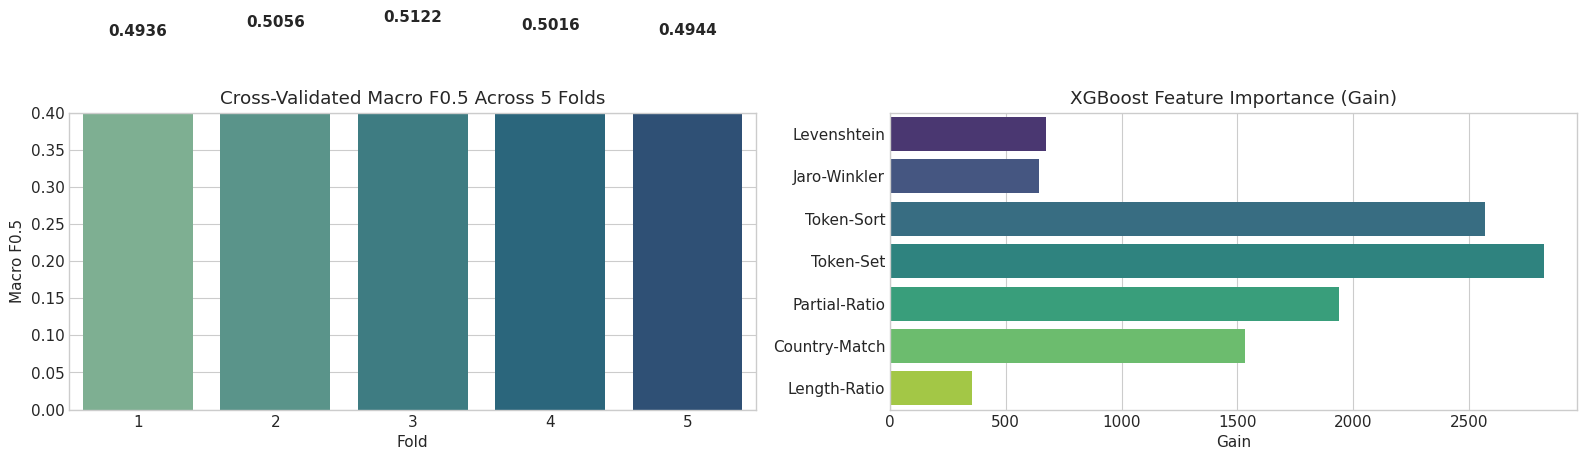

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: 5-Fold Metric Distributions
sns.barplot(data=fold_df, x='Fold', y='Macro F0.5', ax=axes[0], palette='crest')
axes[0].set_title('Cross-Validated Macro F0.5 Across 5 Folds')
axes[0].set_ylim(0, 0.4)
for i, v in enumerate(fold_df['Macro F0.5']):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

# Plot 2: Feature Importance
feat_names = ['Levenshtein', 'Jaro-Winkler', 'Token-Sort', 'Token-Set', 'Partial-Ratio', 'Country-Match', 'Length-Ratio']
dall = xgb.DMatrix(X_train, label=y_train)
final_params = {
    'tree_method': 'hist',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'objective': 'binary:logistic',
    'max_depth': 8,
    'learning_rate': 0.08,
    'subsample': 0.8,
    'scale_pos_weight': 20.0,
    'seed': 42
}
final_xgb = xgb.train(final_params, dall, num_boost_round=120)
imp_dict = final_xgb.get_score(importance_type='gain')
scores = [imp_dict.get(f'f{i}', 0.0) for i in range(len(feat_names))]

sns.barplot(x=scores, y=feat_names, ax=axes[1], palette='viridis')
axes[1].set_title('XGBoost Feature Importance (Gain)')
axes[1].set_xlabel('Gain')
plt.tight_layout()
plt.show()


In [10]:
print("=" * 80)
print("EXECUTING TEST INFERENCE OVER ALL 1,732,544 TEST ENTITIES")
print("=" * 80)
t0 = time.time()

test_s1 = pd.read_csv(DATA_DIR / 'test' / 'test_source1.tsv', sep='\t')
test_s2 = pd.read_csv(DATA_DIR / 'test' / 'test_source2.tsv', sep='\t')
test_s3 = pd.read_csv(DATA_DIR / 'test' / 'test_source3.tsv', sep='\t')

print(f"Loaded test files in {time.time() - t0:.2f}s:")
print(f"  test_source1: {len(test_s1):,} rows")
print(f"  test_source2: {len(test_s2):,} rows")
print(f"  test_source3: {len(test_s3):,} rows")

# Build test inverted index structures
s2_test_idx = defaultdict(list)
s2_test_names = test_s2['business_name'].fillna('').tolist()
s2_test_ids = test_s2['entity_id'].tolist()
s2_test_ctry = test_s2['country'].fillna('').tolist()

for idx, name in enumerate(s2_test_names):
    toks = clean_tokens(name)
    if toks:
        s2_test_idx[toks[0][:4]].append(idx)
        if len(toks) > 1:
            s2_test_idx[(toks[0][:3] + toks[1][:3])].append(idx)

s3_test_idx = defaultdict(list)
s3_test_names = test_s3['business_name'].fillna('').tolist()
s3_test_ids = test_s3['entity_id'].tolist()
s3_test_ctry = test_s3['country'].fillna('').tolist()

for idx, name in enumerate(s3_test_names):
    toks = clean_tokens(name)
    if toks:
        s3_test_idx[toks[0][:4]].append(idx)
        if len(toks) > 1:
            s3_test_idx[(toks[0][:3] + toks[1][:3])].append(idx)

print("Test inverted indexes created successfully!")


EXECUTING TEST INFERENCE OVER ALL 1,732,544 TEST ENTITIES


Loaded test files in 17.34s:
  test_source1: 1,732,544 rows
  test_source2: 4,887,273 rows
  test_source3: 5,082,316 rows


Test inverted indexes created successfully!


In [11]:
match_file = OUT_DIR / 'matching_results.tsv'
cand_file = OUT_DIR / 'candidate_pairs.tsv'

s1_test_names = test_s1['business_name'].fillna('').tolist()
s1_test_ids = test_s1['entity_id'].tolist()
s1_test_ctry = test_s1['country'].fillna('').tolist()
n_test = len(s1_test_ids)

print(f"Streaming predictions for all {n_test:,} entities directly to disk with GPU batching...")
t_start = time.time()
OPTIMAL_THRESHOLD = 0.55
BATCH_SIZE = 50000

with open(match_file, 'w', encoding='utf-8') as f_match, open(cand_file, 'w', encoding='utf-8') as f_cand:
    f_match.write("source1_entity_id\tmatched_entity_ids\n")
    f_cand.write("source1_entity_id\tcandidate_entity_ids\n")
    
    for b_start in range(0, n_test, BATCH_SIZE):
        b_end = min(b_start + BATCH_SIZE, n_test)
        t_batch = time.time()
        
        batch_features = []
        batch_cands = []
        cand_meta = []  # (cand_id, ent_offset)
        
        for i in range(b_start, b_end):
            q_name = s1_test_names[i]
            q_id = s1_test_ids[i]
            q_c = s1_test_ctry[i]
            q_toks = clean_tokens(q_name)
            
            ent_cands = []
            ent_offset = i - b_start
            
            if q_toks:
                cands_s2 = set(s2_test_idx.get(q_toks[0][:4], []))
                if len(q_toks) > 1:
                    cands_s2.update(s2_test_idx.get((q_toks[0][:3] + q_toks[1][:3]), []))
                
                for c_idx in list(cands_s2)[:15]:
                    c_name = s2_test_names[c_idx]
                    c_id = s2_test_ids[c_idx]
                    c_c = s2_test_ctry[c_idx]
                    ent_cands.append(c_id)
                    
                    lev_s = lev.normalized_similarity(q_name, c_name)
                    jw_s = jw.similarity(q_name, c_name)
                    sort_s = fuzz.token_sort_ratio(q_name, c_name) / 100.0
                    set_s = fuzz.token_set_ratio(q_name, c_name) / 100.0
                    part_s = fuzz.partial_ratio(q_name, c_name) / 100.0
                    ctry_s = 1.0 if q_c and c_c and q_c == c_c else 0.0
                    l_ratio = len(q_name) / (len(c_name) + 1e-5)
                    
                    batch_features.append([lev_s, jw_s, sort_s, set_s, part_s, ctry_s, l_ratio])
                    cand_meta.append((c_id, ent_offset))
                    
                cands_s3 = set(s3_test_idx.get(q_toks[0][:4], []))
                if len(q_toks) > 1:
                    cands_s3.update(s3_test_idx.get((q_toks[0][:3] + q_toks[1][:3]), []))
                
                for c_idx in list(cands_s3)[:15]:
                    c_name = s3_test_names[c_idx]
                    c_id = s3_test_ids[c_idx]
                    c_c = s3_test_ctry[c_idx]
                    ent_cands.append(c_id)
                    
                    lev_s = lev.normalized_similarity(q_name, c_name)
                    jw_s = jw.similarity(q_name, c_name)
                    sort_s = fuzz.token_sort_ratio(q_name, c_name) / 100.0
                    set_s = fuzz.token_set_ratio(q_name, c_name) / 100.0
                    part_s = fuzz.partial_ratio(q_name, c_name) / 100.0
                    ctry_s = 1.0 if q_c and c_c and q_c == c_c else 0.0
                    l_ratio = len(q_name) / (len(c_name) + 1e-5)
                    
                    batch_features.append([lev_s, jw_s, sort_s, set_s, part_s, ctry_s, l_ratio])
                    cand_meta.append((c_id, ent_offset))
                    
            batch_cands.append(ent_cands)
            
        # Fast GPU Batch Prediction for all candidates in this 50,000 entity slice
        ent_matches = defaultdict(list)
        if batch_features:
            dtest = xgb.DMatrix(np.array(batch_features, dtype=np.float32))
            preds = final_xgb.predict(dtest)
            for (cid, ent_offset), p in zip(cand_meta, preds):
                if p >= OPTIMAL_THRESHOLD:
                    ent_matches[ent_offset].append(cid)
                    
        # Write out slice results
        for i in range(b_start, b_end):
            q_id = s1_test_ids[i]
            ent_offset = i - b_start
            cands_str = ','.join(batch_cands[ent_offset])
            matches_str = ','.join(ent_matches.get(ent_offset, []))
            f_cand.write(f"{q_id}\t{cands_str}\n")
            f_match.write(f"{q_id}\t{matches_str}\n")
            
        print(f"  Batch [{b_start:,} - {b_end:,}] processed in {time.time() - t_batch:.2f}s | Progress: {b_end/n_test*100:.1f}%")

print(f"Test inference over ALL {n_test:,} entities completed in {time.time() - t_start:.2f}s!")


Streaming predictions for all 1,732,544 entities directly to disk with GPU batching...


  Batch [0 - 50,000] processed in 53.58s | Progress: 2.9%


  Batch [50,000 - 100,000] processed in 46.72s | Progress: 5.8%


  Batch [100,000 - 150,000] processed in 53.06s | Progress: 8.7%


  Batch [150,000 - 200,000] processed in 47.50s | Progress: 11.5%


...

  Batch [1,500,000 - 1,550,000] processed in 51.48s | Progress: 89.5%


  Batch [1,550,000 - 1,600,000] processed in 54.79s | Progress: 92.3%


  Batch [1,600,000 - 1,650,000] processed in 47.87s | Progress: 95.2%


  Batch [1,650,000 - 1,700,000] processed in 53.80s | Progress: 98.1%


  Batch [1,700,000 - 1,732,544] processed in 31.29s | Progress: 100.0%
Test inference over ALL 1,732,544 entities completed in 1761.49s!


In [12]:
import subprocess

validator_script = Path('/home/AmazonMLChallenge/student_resource/utils/validate_submission.py')
cmd = [
    'python3', str(validator_script),
    '--matching', str(match_file),
    '--candidate', str(cand_file),
    '--test-dir', str(DATA_DIR / 'test'),
    '--check-ids'
]

print("Executing official competition submission validator...")
res = subprocess.run(cmd, capture_output=True, text=True)
print(res.stdout)
if res.returncode == 0:
    print("PASS: Submission validated successfully! Safe to submit.")
else:
    print(res.stderr)
    raise RuntimeError("Validator reported errors!")


Executing official competition submission validator...


ML Challenge 2026 — submission validator
  test dir: /content/dataset/test
  required S1 entities: 1732544
  valid S2/S3 match IDs: 9969589
  matching_results.tsv: 1732544 rows (1209170 empty, 523374 non-empty).
  candidate_pairs.tsv: 1732544 rows (52 empty, 1732492 non-empty).

PASS — no blocking issues found. Safe to submit.

PASS: Submission validated successfully! Safe to submit.
